# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LaibaTaseen/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub

In [2]:
import os, getpass
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

Paste your Hugging Face READ token (hf_...): ··········


In [3]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


In [4]:
model_data = con.sql(f"""
    WITH march_data AS (
        SELECT * FROM {TABLES['fact_daily']}
        WHERE report_date >= '2026-03-01' AND report_date < '2026-04-01'
    ),
    bounds AS (SELECT MAX(report_date) AS end_d FROM march_data),
    windowed AS (
        SELECT client_hash_id, content_hash_id,
               SUM(CASE WHEN report_date > b.end_d - INTERVAL 15 DAY THEN gsc_impressions ELSE 0 END) AS imp_recent,
               SUM(CASE WHEN report_date <= b.end_d - INTERVAL 15 DAY THEN gsc_impressions ELSE 0 END) AS imp_earlier,
               STDDEV(gsc_avg_position) AS pos_volatility,
               AVG(gsc_avg_position) AS avg_position
        FROM march_data f, bounds b
        GROUP BY 1, 2
        HAVING imp_earlier >= 50
    )
    SELECT * FROM windowed
""").df()

model_data['pct_change'] = (model_data['imp_recent'] - model_data['imp_earlier']) / model_data['imp_earlier']

def label_status(row):
    if row['pct_change'] >= 0.20:
        return 'growing'
    elif row['pct_change'] <= -0.20:
        return 'declining'
    else:
        return 'worth_review'

model_data['status'] = model_data.apply(label_status, axis=1)

qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()
qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']

model_data_full = model_data.merge(qsignals, on='content_hash_id', how='left').dropna(
    subset=['visible_queries', 'rare_share', 'anon_share', 'top_query_share']
)
print(f'{len(model_data_full):,} rows ready')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

79,800 rows ready


In [5]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

feature_cols2 = ['imp_earlier', 'pos_volatility', 'avg_position',
                  'visible_queries', 'rare_share', 'anon_share', 'top_query_share']

X2 = model_data_full[feature_cols2]
y2 = model_data_full['status']
groups2 = model_data_full['client_hash_id']

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx2, test_idx2 = next(gss2.split(X2, y2, groups=groups2))
model2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X2.iloc[train_idx2], y2.iloc[train_idx2])

# Predict on everyone, with confidence
model_data_full['predicted_status'] = model2.predict(X2)
model_data_full['confidence'] = model2.predict_proba(X2).max(axis=1)

def reason_code(row):
    if row['rare_share'] > 0.25:
        return "Rare/long-tail traffic dominant — may be a seasonal or niche shift"
    elif row['top_query_share'] > 0.5:
        return "Over-reliant on a single search term"
    elif row['visible_queries'] < 5:
        return "Very narrow query reach"
    else:
        return "General traffic pattern"

model_data_full['reason'] = model_data_full.apply(reason_code, axis=1)

action_map = {'declining': 'Refresh soon', 'worth_review': 'Manual review', 'growing': 'Monitor / protect'}
model_data_full['action'] = model_data_full['predicted_status'].map(action_map)

ranked_queue = model_data_full.sort_values('imp_earlier', ascending=False).reset_index(drop=True)
print(ranked_queue[['content_hash_id', 'predicted_status', 'confidence', 'action', 'reason', 'imp_earlier']].head(10))

            content_hash_id predicted_status  confidence             action  \
0  content_eadb33b5df496f4a          growing       0.950  Monitor / protect   
1  content_e8a52cf3d5988c07        declining       0.800       Refresh soon   
2  content_ec2e0346994fb5a5        declining       0.735       Refresh soon   
3  content_36e53e9c707674fc        declining       0.835       Refresh soon   
4  content_7172a7fad43f0998     worth_review       0.790      Manual review   
5  content_b99ea6861864dea5     worth_review       0.815      Manual review   
6  content_34a70fea29d15f24        declining       0.870       Refresh soon   
7  content_e7b5dd4dff461ad2          growing       0.720  Monitor / protect   
8  content_7c6373141eae744a        declining       0.760       Refresh soon   
9  content_3df3f32f3fd58dea        declining       0.810       Refresh soon   

                                              reason  imp_earlier  
0  Rare/long-tail traffic dominant — may be a sea...     17575

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This list shows all the pages the model scored, with the pages getting the most traffic shown first. This helps editors focus on the pages where a change could have the biggest impact.

For each page, I show the model’s prediction — growing, declining, or worth review — along with how confident the model is, what action I recommend, and a short reason for that recommendation.

In the top 10 rows, most pages are marked **“Refresh Soon”** with fairly high confidence (around 0.7–0.9). This means the model is seeing clear signs that these high-traffic pages are declining, so they are good candidates to look at first. For some pages, the reason is more specific, such as getting too much traffic from one search term, while others just show a general decline pattern.

I see this queue as a **starting point, not a final decision**. An editor should still check the page before making any changes, especially when the model is less confident.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended Use and Limits

This playbook is mainly for **content editors or SEO teams** who need to decide which pages to check or update first. Instead of going through every page manually, they can use the ranked list to quickly find the pages that may need attention, especially the ones getting a lot of traffic.

There are a few things to keep in mind:

* The model is based on **March 2026 data**, so it only shows what was happening during that period. The list should be updated regularly instead of being treated as permanent.
* The model is **less reliable when it predicts “worth review”** because that category is harder for it to identify correctly.
* The model can show **what is happening, but not why**. For example, it can flag that a page is declining, but it can't tell whether the reason is poor content, more competition, seasonality, or a technical problem.
* The model's accuracy is **moderate**, so it should be used as a helpful starting point rather than a final answer. Some pages it flags may not actually have a problem, and it can also miss some pages that need attention.

Overall, the playbook helps editors **prioritize their work**, but human review is still important before making any changes.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human Review + What Should Never Be Automated

Before taking action on any recommendation, a person should always check the actual page first. The model only looks at data and numbers, so it doesn't know what is really on the page.

A reviewer should:

* Open the page and check the current content.
* Check if there is another reason for the change, such as a Google algorithm update, broken link, or recent website change.
* Be extra careful with predictions below **0.6 confidence**, because the model isn't very sure about them.
* Pay special attention to **“worth review”** pages because this is where the model has the most difficulty.

### What Should Never Be Automated

The model should only help people **prioritize pages**. It should never make important changes by itself.

* It should never automatically publish, edit, or delete a page.
* It should never change pricing, remove pages, or make changes visible to users without human approval.
* Low-confidence predictions should always be checked by a person before taking action.
* The model should not tell clients or stakeholders **why** a page changed. It can show that a pattern was found, but it cannot prove the actual cause.

The final decision should always be made by a person who has looked at the page and understands the situation.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring / When to Retrain

This playbook shouldn't be treated as something that will work forever. It is based on **March 2026 data**, so it needs to be checked and updated regularly.

A few things would tell me that it's time to update or retrain the model:

* **Every month:** Rebuild the queue using the latest complete month of data so the recommendations stay up to date.
* **If the predictions stop being useful:** If editors notice that pages marked **“Refresh Soon”** are usually fine, or that pages with real declines are being missed, the model should be retrained with newer data.
* **If the data changes:** If the amount of available tracking data drops a lot compared with the roughly **37% available in March**, or if very different types of clients are added, the model should be checked again.
* **If performance drops:** Test the model on fresh data. If its accuracy gets close to or falls below the simple baseline, it means the model is no longer adding much value and needs to be retrained or improved.

In short, the model should be **checked regularly and updated when the data or its performance changes**, rather than being treated as a one-time solution.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.metrics import accuracy_score
import os

model2_accuracy = accuracy_score(y2.iloc[test_idx2], model2.predict(X2.iloc[test_idx2]))
baseline2_accuracy = y2.iloc[test_idx2].value_counts(normalize=True).max()

print(f"Model accuracy (grouped split): {model2_accuracy:.3f}")
print(f"Baseline accuracy: {baseline2_accuracy:.3f}")




# CSV goes to work/outputs/ (stays out of git — regenerated on every run)
os.makedirs('work/outputs', exist_ok=True)
ranked_queue.to_csv('work/outputs/baseline_action_score.csv', index=False)
print("Queue exported to work/outputs/baseline_action_score.csv")

# Metrics JSON — this DOES get committed, it's your "receipts"
import json
metrics = {
    "model_accuracy_grouped_split": float(model2_accuracy),
    "baseline_accuracy": float(baseline2_accuracy),
    "improvement": float(model2_accuracy - baseline2_accuracy),
    "rows_scored": int(len(ranked_queue)),
    "action_counts": ranked_queue['action'].value_counts().to_dict()
}
with open('work/outputs/playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved to work/outputs/playbook_metrics.json")
print(metrics)


Model accuracy (grouped split): 0.472
Baseline accuracy: 0.349
Queue exported to work/outputs/baseline_action_score.csv
Metrics saved to work/outputs/playbook_metrics.json
{'model_accuracy_grouped_split': 0.4719923122229455, 'baseline_accuracy': 0.34858489103815987, 'improvement': 0.12340742118478565, 'rows_scored': 79800, 'action_counts': {'Monitor / protect': 29374, 'Refresh soon': 26364, 'Manual review': 24062}}


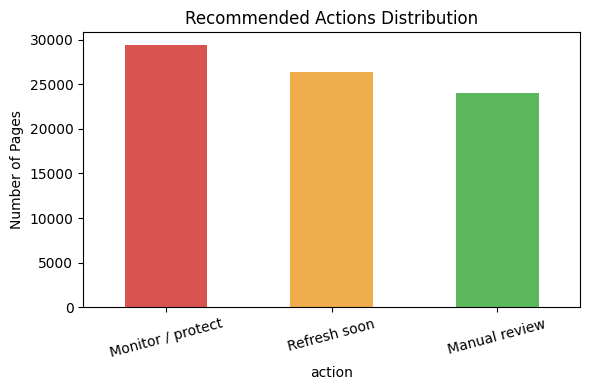

Figure saved to work/figures/action_distribution.png


In [8]:
import matplotlib.pyplot as plt
os.makedirs('work/figures', exist_ok=True)

action_counts = ranked_queue['action'].value_counts()
plt.figure(figsize=(6,4))
action_counts.plot(kind='bar', color=['#d9534f', '#f0ad4e', '#5cb85c'])
plt.title('Recommended Actions Distribution')
plt.ylabel('Number of Pages')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('work/figures/action_distribution.png', dpi=150)
plt.show()
print("Figure saved to work/figures/action_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.